
revision version log:
v1- created 1/14/26
-importing processing code from revision cloud autoencoder iteration. importing modeling code from local_Fig_decode_setup_v18.ipynb


original changelog:
v9- 9/26/24'; added updated time-series importing logic to ensure congruence across different csripts.
10/10/24; added Late IA vs Early RS comparison for decoding (+ weight testing)
using new packaging logic develoepd ~ v7
v11- 10/29/24
-adding cross-stage out of distribution testing for decoding (e.g. train on IA Error vs RS Erorr, test on IA correct vs RS Correct)
v12- 11/11/24 running on 3,15,250, 0.01 abs spike detection params
v13- 11/14/24- running on gauss_smooth + 80% cutoff + temporal dedup, also deleting PCA save step as you are regenerating PC projection with new boostrap pulls in the plotting version of this
v15- 12/4/24- testing # of Early RS COrrect trials occuring b4 and after the Early RS Error trials.
v18- drop time-dependent activity decoding, introduced stratified kfold split


## Setup


In [1]:
%load_ext autoreload
%autoreload 2
from __future__ import annotations
import os
import sys
from pathlib import Path
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import shutil
import time
import json
from datetime import datetime
from functools import partial
from sklearn import svm, metrics, model_selection

from joblib import Parallel, delayed  # from functools import partial #for specific type of parallel deployment
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

#load preprocess specific functions
import notebook_setup
info = notebook_setup.setup()
# from run_manifest import create_run_manifest, update_run_database
from config_preprocessing import load_config
from analysis_config_loader import load_analysis_config  # new import, personal config 

preprocess_func_folder = Path(info["repo_root"]) / "preprocess_functions"
sys.path.append(str(preprocess_func_folder)) #add preprocess_functions folder to path to load modules
# from detect_cell_enrichment import get_cell_stage_enrichment, get_cell_ensemble_info_per_subject
from preprocessing_utils import dataset_obj_to_df, transform_all_datasets, extract_trial_windows, create_subject_trial_tseries_df
from preprocess_functions.shuffle_methods import prepare_shuffle_data, create_shuffled_df_preconverted, log_shuffle_run, get_latest_shuffle_folder, load_latest_shuffle_run
from preprocess_data import hyper_param_dict, bin_rotate_timeseries, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, drop_end_bins_of_trials, drop_start_bins_of_trials, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import *
from phase_enrich_timeseries_decode import plot_unit_enrich_by_phase_summary

# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sns_plotting_config import * #import dicts containing default plot params
try:
    pd.get_option('mode.use_inf_as_null')
except pd._config.config.OptionError:
    pd._config.config.register_option('mode.use_inf_as_null', False, "Deprecated - for seaborn 0.12.x compatibility")
    
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)

#import local yaml for env preset variables
config_path = Path(r"analysis_config.yaml")  # adjust as needed
analysis_config = load_analysis_config(config_path)
stage_names = analysis_config.task_phase_names
print(analysis_config)

# Load general file configuration
config = load_config('config.yaml')
data_type = config['data']['data_type_used']
preprocessing = config['preprocessing']
shuffle_cfg = config['shuffles']
print(config)

# Create unique run ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
START_TIME = time.time()

# Create output directory with run ID
results_dir = config['data']['results_dir']
run_output_dir = results_dir / 'shuffles' / f"shuffle_run_{RUN_ID}"
run_output_dir.mkdir(parents=True, exist_ok=True)

#set data location
data_dir = config['data']['data_dir']
source_dataset_location= config['data']['source_dataset_location']

#hardcoded/old links for checking
hardcode_results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")
hardcode_data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')
hardcode_source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19") #source dataset location has files created 10-26-2024

#print config paths for verification
print(f"Run ID: {RUN_ID}, Started: {datetime.now()}")
print(f"\nFolders used in run ID: {RUN_ID}")
print(f"Results dir: {results_dir}")
print(f"Data dir: {data_dir}")
print(f"Source dataset location: {source_dataset_location}")
# Copy config to output directory for reference
shutil.copy('config.yaml', run_output_dir / 'config_used.yaml')

##IMPORT TIME_SERIES
#declare loc/names of files to read
output_folder = os.getcwd() +"/output/"
new_trial_df_filename = Path(r"python-made_trial_timeseries_raster_2025-12-21 12.parquet")
# trial_df_filename = data_folder +  f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
trial_df_filename = data_dir /  new_trial_df_filename
print(f"loading_dataset")
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
trial_tseries_df_norm.tail()
stage_col = 'task_phase_vec'
stage_names = sorted(trial_tseries_df_norm[stage_col].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], ['subject_name', 'neuron_id','geno_day', stage_col], numeric_col) 
# note informative stats for refernce later if necessary
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = 'neuron_id', subj_name_col = 'subject_name')#.rename({'neuron_id': "unique_ID"},axis = 1) # get subj level dfs
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')['neuron_id'].nunique()
subject_stage_info_df.tail()


C:\Users\13car\AppData\Local\Temp\ipykernel_39676\3588098111.py:43: FutureWarning: 
: boolean
    use_inf_as_null had been deprecated and will be removed in a future
    version. Use `use_inf_as_na` instead.

  pd.get_option('mode.use_inf_as_null')


Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_thresh=2.5, final_thresh2=12.5, final_thresh3=20, final_thresh4_abs=0.01, drop_low_value

,subject_name,geno_day,task_phase_vec,neuron_id,num_enriched_units,num_units,trial_num,count_of_trials,over_5
196,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-100, 9_3_HET_RS3-129, 9_3_HET_RS3...",23,171,"[3, 5]",2,"[False, False]"
197,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-124, 9_3_HET_RS3-129, 9_3_HET_RS3...",10,171,"[17, 19, 21]",3,"[True, True, True]"
198,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-128, 9_3_HET_RS3-138, 9_3_HET_RS3...",12,171,"[18, 20]",2,"[True, True]"
199,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-129, 9_3_HET_RS3-138, 9_3_HET_RS3...",16,171,"[12, 13, 14, 15, 16]",5,"[True, True, True, True, True]"
200,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-130, 9_3_HET_RS3-169, 9_3_HET_RS3...",4,171,"[34, 35, 36, 38]",4,"[True, True, True, True]"


<Figure size 640x480 with 0 Axes>

## Import neural datasets + set parameters

In [2]:
# datasets_location = "/content/drive/MyDrive/Colab Notebooks/"# TACO_location = "Time-series activity datasets"
folder_loc = results_dir
os.chdir(folder_loc)
#make figure storage
cwd = os.getcwd()
print(f" CWD: {cwd}")

date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
output_folder =folder_loc / Path(f"figure_5_prep_mid_decoding figures_{date_tag}/")
make_folder(output_folder)
os.chdir(output_folder)
subfolder_names= make_figtype_subfolders(output_folder)
#save hyperparameters: 
# open a file for writing
with open('hyper_param_dict.json', 'w') as f:     # write the dictionary to the file in JSON format
    json.dump(hyper_param_dict, f)
## save metatdata of current run
f = open("latest_figure_5_decode_setup_run_source_data.txt", "w")
f.write(f"latest_figure_5_decode_setup_source Activity time-series record used : {str(new_trial_df_filename)}")
f.close()
os.getcwd()

 CWD: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\svg_plots' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\pdf_plots' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\png_plots' has been created.


'C:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\results\\figure_5_prep_mid_decoding figures_16_Jan_2026'

#### Import Single Trial time-series dataset with enrichment information

#### Set parameter name/info for reference


In [3]:
#set unit name and type of data
data_type = 'post_outcome_activity'
units = 'cells'
unit_ID_col=  "neuron_id"
#phase related information
single_trial_tseries_w_enrich = trial_tseries_df_norm
id_col = [col for col in single_trial_tseries_w_enrich.columns if 'id' in col.lower()][0]
print(id_col)
phase_names = single_trial_tseries_w_enrich.task_phase_vec.unique()
#determine comparisosn to be decoding on
class_comparisons = [
    [phase_names[0], phase_names[1]], #early IA corr vs. early IA err
    [phase_names[0], phase_names[3]],#- early IA corr vs. early RS corr
    [phase_names[1], phase_names[4]],#  - early IA err vs.l early RS err
    [phase_names[3], phase_names[4]],#- early RS corr vs. early RS err
    [phase_names[2], phase_names[5]],#- late IA vs. late RS
    [phase_names[0], phase_names[2]],#- early IA corr vs. late IA
    [phase_names[3], phase_names[5]],#- early RS corr vs. late RS
    [phase_names[2], phase_names[3]],#late IA vs early RS corr
                     ]
print(numeric_col)
print(phase_names)
class_comparisons

neuron_id
Index(['0.0s to 0.25s', '0.25s to 0.5s', '0.5s to 0.75s', '0.75s to 1.0s',
       '1.0s to 1.25s', '1.25s to 1.5s', '1.5s to 1.75s', '1.75s to 2.0s',
       '2.0s to 2.25s', '2.25s to 2.5s', '2.5s to 2.75s', '2.75s to 3.0s',
       '3.0s to 3.25s', '3.25s to 3.5s', '3.5s to 3.75s', '3.75s to 4.0s',
       '4.0s to 4.25s', '4.25s to 4.5s', '4.5s to 4.75s', '4.75s to 5.0s',
       '5.0s to 5.25s', '5.25s to 5.5s', '5.5s to 5.75s', '5.75s to 6.0s',
       '6.0s to 6.25s', '6.25s to 6.5s', '6.5s to 6.75s', '6.75s to 7.0s',
       '7.0s to 7.25s', '7.25s to 7.5s', '7.5s to 7.75s', '7.75s to 8.0s',
       '8.0s to 8.25s', '8.25s to 8.5s', '8.5s to 8.75s', '8.75s to 9.0s',
       '9.0s to 9.25s', '9.25s to 9.5s', '9.5s to 9.75s', '9.75s to 10.0s',
       '10.0s to 10.25s', '10.25s to 10.5s', '10.5s to 10.75s',
       '10.75s to 11.0s', '11.0s to 11.25s', '11.25s to 11.5s',
       '11.5s to 11.75s', '11.75s to 12.0s', '12.0s to 12.25s',
       '12.25s to 12.5s', '12.5s to 12.75s', '1

[['Early_IA_Correct', 'Early_IA_Error'],
 ['Early_IA_Correct', 'Early_RS_Correct'],
 ['Early_IA_Error', 'Early_RS_Error'],
 ['Early_RS_Correct', 'Early_RS_Error'],
 ['Late_IA', 'Late_RS'],
 ['Early_IA_Correct', 'Late_IA'],
 ['Early_RS_Correct', 'Late_RS'],
 ['Late_IA', 'Early_RS_Correct']]

## Create summary viz of enriched units info and frame data


In [4]:
## summary plot function 
def plot_unit_enrich_by_phase_summary(fig_size, trial_type_by_subj,phase_enrichment_by_subj,geno_order, phase_names, numeric_col, name_col = 'name'):
    unit_count_fig, axs = plt.subplots(2,2, figsize = fig_size, layout = 'constrained')
    axs = axs.flat
    # plot # recorded trials by phase
    sns.heatmap(ax = axs[0], data= trial_type_by_subj.set_index(name_col).drop('geno_day', axis = 1).T, annot = True)
    axs[0].set_title('# of recorded trials in each phase, by dataset');
    #plot timebin recorded of a phase, by dataset
    sns.heatmap(ax = axs[1], data= trial_type_by_subj.set_index(name_col).drop('geno_day', axis = 1).T*len(numeric_col),linewidth = 0.1, annot = True, fmt = '.0f')
    axs[1].set_title('# of recorded timebins in phase, by dataset');
    # plot # cells enriched in phase, by phase
    sns.heatmap(ax = axs[2], data=phase_enrichment_by_subj.set_index(name_col).drop('geno_day', axis = 1).T, linewidth = 0.1, annot = True, fmt = '.0f')
    axs[2].set_title('# of cells enriched in phase, by dataset');
    #total enrichment by geno_day
    sns.heatmap(ax = axs[3], data=phase_enrichment_by_subj.groupby('geno_day').sum().loc[geno_order,phase_names].T,linewidth = 0.1, annot = True, fmt = '.0f')
    axs[3].set_title('Total # units in pseudopop enriched in phase, by geno_day');
    #figre metadata
    unit_count_fig.subplots_adjust(top = 0.9);
    unit_count_fig.suptitle(f"Summary of Total # of trials and # of usable timebins for each dataset, by task phase");
    return unit_count_fig, axs


C:\Users\13car\AppData\Local\Temp\ipykernel_39676\2245857508.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.heatmap(ax = axs[3], data=phase_enrichment_by_subj.groupby('geno_day').sum().loc[geno_order,phase_names].T,linewidth = 0.1, annot = True, fmt = '.0f')
C:\Users\13car\AppData\Local\Temp\ipykernel_39676\2245857508.py:18: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  unit_count_fig.subplots_adjust(top = 0.9);


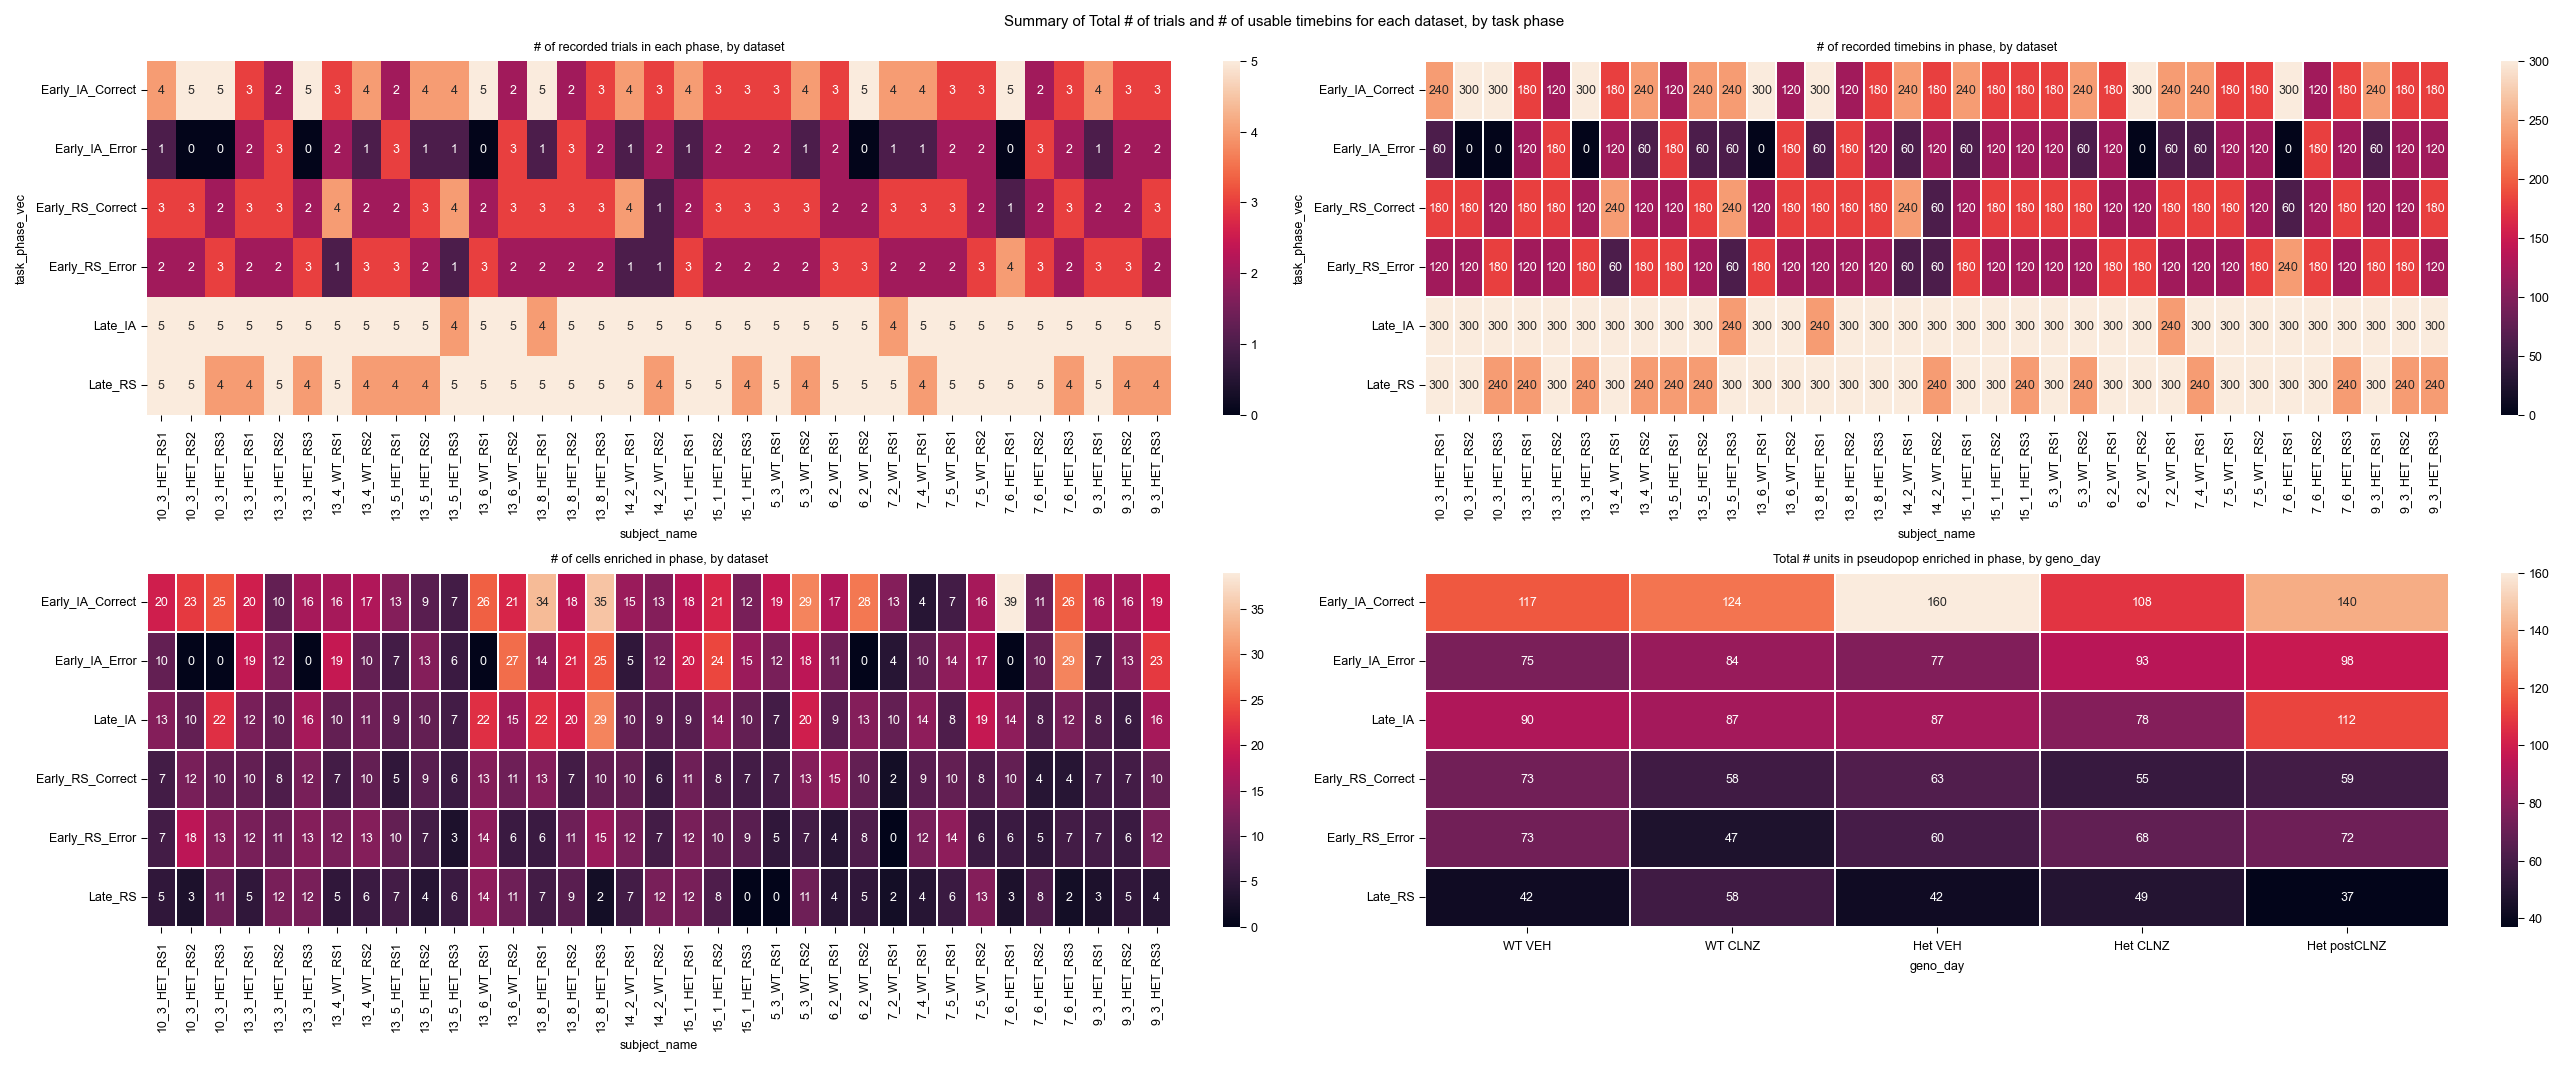

In [5]:

#gather trial types
trial_type_by_subj = get_num_trials_by_type_in_subject(single_trial_tseries_w_enrich, task_phase_col= 'task_phase_vec', name_col = 'subject_name').fillna(0);
trial_type_by_subj[phase_names] = trial_type_by_subj[phase_names].astype(int)
neuron_enrichment =  single_trial_tseries_w_enrich.groupby(['subject_name', 'geno_day', id_col])[phase_names].mean().reset_index()
phase_enrichment_by_subj = neuron_enrichment[list(phase_names) + ['subject_name', 'geno_day']].groupby(by = ['subject_name', 'geno_day']).sum().reset_index()

#make figures
unit_count_fig, axs = plot_unit_enrich_by_phase_summary((17,7), trial_type_by_subj,phase_enrichment_by_subj,geno_order_w_WT_CLNZ, phase_names,numeric_col, name_col = 'subject_name')
#save as a fig
pdf_name = output_folder / Path(f"Enrichment of {units} and # of samples per phase")
save_fig_as_filetype_list(unit_count_fig, pdf_name , subfolder_names, ['pdf', 'png'])

### New Pseudopop generation by resampling cell activity time-series

In [6]:
#imported from autoencoder:
# ## helper functions imported from phase_enrich_timeseries_decode.py module
def get_dataset_names_in_geno(dataset_name_by_geno_day,
                              geno_day,
                              subject_name_col = 'subject_name'):
    datasets_in_geno = dataset_name_by_geno_day.loc[dataset_name_by_geno_day.geno_day == geno_day,subject_name_col].values[0] #get name of datasets in current geno_day setup
    return datasets_in_geno

 ## imported subfunc for cuDF speedup
def get_tseries_of_dataset(timeseries_df, 
                           dataset_name, 
                           subject_name_col = 'subject_name'):
    #get time-series that are occurign in phase of interest
    dataset_df_slice = timeseries_df.loc[timeseries_df[subject_name_col] == dataset_name]
    return dataset_df_slice

def get_tseries_in_phase(timeseries_df, phase_name):
    phase_dataset_df_slice = timeseries_df.loc[timeseries_df.task_phase_vec == phase_name]
    return phase_dataset_df_slice

def get_tseries_phase_enrich_cells(tseries_df, unit_ID_col, enrichment_ID_df, dataset_name, e_phase_name):
    enrich_in_phase_unit_IDs = get_dataset_units_enrich_in_phase(enrichment_ID_df, unit_ID_col, dataset_name, e_phase_name) #get unit IDs that are enriched in phase of interest
    enrich_in_phase_dataset_df = tseries_df.loc[tseries_df[unit_ID_col].isin(enrich_in_phase_unit_IDs)]#get unit time-series only if they enriched in phase of interest
    return enrich_in_phase_dataset_df, enrich_in_phase_unit_IDs

def get_dataset_units_enrich_in_phase(enrich_unit_by_name_phase_df,
                                       unit_ID_col,
                                         dataset_name,
                                           stage_of_interest,
                                           subject_name_col = 'subject_name'):
    name_mask = enrich_unit_by_name_phase_df[subject_name_col] == dataset_name
    phase_mask = enrich_unit_by_name_phase_df.task_phase_vec == stage_of_interest
    enrich_in_phase_unit_IDs =enrich_unit_by_name_phase_df.loc[phase_mask&name_mask, unit_ID_col].values[0]
    return enrich_in_phase_unit_IDs

def horzcat_all_trials(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=None):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col]
    grouped = {
        trial: group.set_index(unit_col_name)[tseries_cols]
        for trial, group in timeseries_df.groupby('trial_num', sort=False)
    }
    return pd.concat(grouped.values(), axis=1)
def horzcat_all_trials_original(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=None):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col] 
    trial_slice_storage = []
    for trial in timeseries_df.trial_num.unique():
        trial_slice = timeseries_df.loc[timeseries_df.trial_num == trial].set_index(unit_col_name)
        trial_slice_storage.append(trial_slice.loc[:,tseries_cols])
    return pd.concat(trial_slice_storage, axis=1)

# Test
result_orig = horzcat_all_trials_original(trial_tseries_df_norm, numeric_col,'neuron_id')
result_opt = horzcat_all_trials(trial_tseries_df_norm, numeric_col,'neuron_id')

print("Identical:", result_orig.equals(result_opt))
print("Shape match:", result_orig.shape == result_opt.shape)
print("Columns match:", list(result_orig.columns) == list(result_opt.columns))
print("Index match:", list(result_orig.index) == list(result_opt.index))
def make_dataset_matrix_store_only(phase_names, 
                                   trial_tseries_df_norm,
                                   unit_ID_col,
                                   enrich_unit_ID_by_name_df,
                                    numeric_col,
                                    trial_list_by_dataset,
                                   dataset_name_by_geno_day,
                                   phase_enrichment_by_subj,
                                     subject_name_col = 'subject_name'):
    """TO- create a dict where key1 = stage the pseudopop is enriched in, key 2 = stage to look for activity of, and key 3- genotype of current datset"""
    ppop_data,stage_geno_tseries = dict(), dict()
    iter_ct = 0
    for e_phase in phase_names:
        ppop_data[e_phase],stage_geno_tseries[e_phase] = {},{}
        print("Get enrich in ",e_phase, "act. in ", phase_names)

        for act_phase in phase_names:
            datasets_w_phase_act = trial_list_by_dataset.loc[trial_list_by_dataset.task_phase_vec == act_phase][subject_name_col].unique()
            ppop_data[e_phase][act_phase],stage_geno_tseries[e_phase][act_phase]= {},{}

            for geno_day in dataset_name_by_geno_day.geno_day.unique():
                datasets_in_geno = get_dataset_names_in_geno(dataset_name_by_geno_day,geno_day)
                geno_dataset_w_act = [name for name in datasets_in_geno if name in datasets_w_phase_act]
                current_ppop_draw = dict()
                
                for dataset in geno_dataset_w_act:
                    iter_ct = iter_ct+1
                    #check if > 0 cells are enriched in stage
                    if phase_enrichment_by_subj.set_index(subject_name_col).loc[dataset, e_phase] > 0:
                        phase_dataset_df = get_tseries_in_phase(get_tseries_of_dataset(trial_tseries_df_norm,dataset), act_phase)
                        e_in_phase_data_df,e_in_stage_ID =get_tseries_phase_enrich_cells(phase_dataset_df, unit_ID_col,
                                                                                         enrich_unit_ID_by_name_df, dataset, e_phase)
                        current_ppop_draw[dataset] =  horzcat_all_trials(e_in_phase_data_df,numeric_col, unit_ID_col)
                ppop_data[e_phase][act_phase][geno_day] =current_ppop_draw
    return ppop_data

Identical: True
Shape match: True
Columns match: True
Index match: True


#### Get all time-series corresponding to dataset N

In [7]:
single_trial_tseries_w_enrich= single_trial_tseries_w_enrich.assign(**{'any_enrichment':  single_trial_tseries_w_enrich[phase_names].sum(axis = 1)})

trial_list_by_dataset = get_trial_num_in_phase_by_dataset( single_trial_tseries_w_enrich, name_col = 'subject_name')
##important- threshold to take datasets with >1 trials per section ( to have enough space of neurons)
trial_list_by_dataset= trial_list_by_dataset[trial_list_by_dataset.count_of_trials >1]
enrich_unit_ID_by_name_df =get_ID_enriched_units_by_phase(single_trial_tseries_w_enrich, ID_col= id_col, bool_col_tseries_enriched = 'enriched_in_phase', subj_name_col = 'subject_name' )
dataset_name_by_geno_day = enrich_unit_ID_by_name_df.groupby('geno_day')['subject_name'].unique().reset_index()
#add unique identifier that's (dataset_name + neuron_ID) to retain neuron ID info

In [8]:
enrich_unit_ID_by_name_df.tail()

,subject_name,geno_day,task_phase_vec,neuron_id,num_enriched_units
196,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-100, 9_3_HET_RS3-129, 9_3_HET_RS3...",23
197,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-124, 9_3_HET_RS3-129, 9_3_HET_RS3...",10
198,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-128, 9_3_HET_RS3-138, 9_3_HET_RS3...",12
199,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-129, 9_3_HET_RS3-138, 9_3_HET_RS3...",16
200,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-130, 9_3_HET_RS3-169, 9_3_HET_RS3...",4


## Find accuracy of decoding in distribution / record results 

#### package all real enrichewd cell activations for future use

In [9]:
## make real dataset storage
dataset_name_by_geno_day
phase_enrichment_by_subj
class_matrix_store  = make_dataset_matrix_store_only(phase_names, single_trial_tseries_w_enrich,unit_ID_col,enrich_unit_ID_by_name_df, numeric_col, trial_list_by_dataset,dataset_name_by_geno_day,phase_enrichment_by_subj)

Get enrich in  Early_IA_Correct act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Early_IA_Error act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Late_IA act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Early_RS_Correct act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Early_RS_Error act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Late_RS act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']


#### Run real decoder

In [10]:
def get_test_precision_recall_acc(test_set_data, test_set_labels, trained_model):
#TO- given model already trained on test set, create prediction vec, then calculate precision and recall
    prediction_vec =trained_model.predict(test_set_data)
    true_positive_vec = test_set_labels*prediction_vec
    ## get score metrics
    precision = (1+np.sum(true_positive_vec))/(1+ np.sum(prediction_vec)) #precision = % of predicted 1 / true 1
    recall = (1+ np.sum(true_positive_vec))/ (1+np.sum(test_set_labels)) #recall =  % of predicted 1/ all 1
    acc = np.mean(prediction_vec == test_set_labels)
    return precision, recall,acc


## new- get cosine sim of class matrices:
def mean_class_cosine_sim(matrix, labels):
    """Cosine similarity between mean vectors of class 0 and class 1."""
    mean_0 = matrix[labels == 0].mean(axis=0)
    mean_1 = matrix[labels == 1].mean(axis=0)
    return np.dot(mean_0, mean_1) / (np.linalg.norm(mean_0) * np.linalg.norm(mean_1))

In [ ]:
from matrix_resample_utils import * 

def run_N_stage_pair_decoders(class_matrix_store,class_comparisons, num_resample, test_size = 0.5, k_folds = 2, n_pseudopop_run_range = [0]):
    '''To- given a predefined range of numbers to uterate over as run #s, run SVM decoding thoese N times on ensemble, stage, and geno-day pairs  '''
    all_run_record_store = []#create storage for all run information for later concat
    #declare variables for local use
    reg_penalty = 'l2'

    
    
    phase_names = class_matrix_store.keys()
    for n_run in n_pseudopop_run_range:
        for e_phase in phase_names:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
            for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys(): #set geno to use
                ensemble_resample_in_phase_dict = {}
                for class_name in phase_names:
                    class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, class_name, geno_day_curr)
                    ensemble_resample_in_phase_dict[class_name] = class_matrix
                
                for phase_count, phase_pair in enumerate(class_comparisons): #once genotype & enrichment filter, specified, compare phase detection
                    class_0,class_1 = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    ## make training set
                    class_mat_0 =ensemble_resample_in_phase_dict[class_0]
                    class_mat_1 =ensemble_resample_in_phase_dict[class_1]
                    concat_matrix,concat_labels =fast_pack_data_local(class_mat_0, class_mat_1,0,1)        #returns concat_matrix, and concat_labels
                    concat_matrix = concat_matrix.T.values #.T.values of concat matrix is to reshape mat into what scikit wants from you
                    
                    cv = model_selection.StratifiedShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices
                    target_info = {"pseudopop_run_num": n_run, 'class_0': class_0,'class_1' : class_1,"enriched_group": e_phase, 'geno_day': geno_day_curr} #speficy info about what classes being decoded
                    # split_accuracy = [] #NOW, ONLY TAKE ACCURACY OF EACH SPLIT AND AVERAGE IT OVER SPLITS 
                    full_cosine_sim = mean_class_cosine_sim(concat_matrix, concat_labels)

                    for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels)), concat_labels)):
                        model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                        trained_model = model.fit(concat_matrix[train,:], concat_labels[train])                 # score_real = trained_model.score( concat_matrix[test,:], concat_labels[test])#get accuracy
                        #get accuracy
                        prediction_vec =trained_model.predict(concat_matrix[test,:])
                        true_pos= np.sum([np.array([prediction_vec == 1]) &  np.array([concat_labels[test]==1])])
                        true_neg= np.sum([np.array([prediction_vec == 0]) &  np.array([concat_labels[test]==0])])
                        false_pos =  np.sum([np.array([prediction_vec == 1]) &  np.array([concat_labels[test]==0])])
                        false_neg =  np.sum([np.array([prediction_vec == 0]) &  np.array([concat_labels[test]==1])])
                        score_real = np.mean(prediction_vec == concat_labels[test])
                        
                        # Calculate cosine similarity between mean class vectors (using training & test data)
                        train_cosine_sim = mean_class_cosine_sim(concat_matrix[train], concat_labels[train])
                        test_cosine_sim = mean_class_cosine_sim(concat_matrix[test], concat_labels[test])

                        # precision, recall,score_real = get_test_precision_recall_acc( concat_matrix[test,:], concat_labels[test], trained_model)
                        curr_split_params = {**target_info,'split': split_count, 'accuracy': score_real,
                                             'num_features_used': trained_model.n_features_in_, 'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0), 
                                             'train_pos_sample':  np.sum(concat_labels[train] ==1), 'train_neg_sample':np.sum(concat_labels[train] ==0),
                                             'test_pos_sample':np.sum(concat_labels[test]==1), 'test_neg_sample': np.sum(concat_labels[test]==0),
                                            'true_pos': true_pos,'true_neg':true_neg,'false_pos':false_pos, 'false_neg' :false_neg,
                                            'train_cosine_sim': train_cosine_sim, 'test_cosine_sim': test_cosine_sim, 'full_cosine_sim': full_cosine_sim
                                            }
                        all_run_record_store.append(curr_split_params)# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated
                    #after finishing split run, average then store
                    #how to average? 
                    # average_acc = np.mean(split_accuracy)
                    # split_summary = {**target_info,'mean_acc': average_acc} 
                    # all_run_record_store.append(split_summary) #append dict
                    # all_run_record_store.append(pd.DataFrame.from_records(split_summary)) #store performance information by split run
    #once done with all bootstraps, create from records
    all_run_record_store =pd.DataFrame.from_records(all_run_record_store)
    return all_run_record_store

In [ ]:
# 5.18.24 stats: #1 run- Wall time: 28.7 s|# 10 runs- 5 minutes|# 20 runs-10min|# 500 runs- 4.5 hours
#5.19.24 stats (single storage, then as needed resample): #5 runs- 1.5 min|#10 iter = 3min 11|#20- 6 min
#hyperparameters for decoding
num_resample = 400
n_pseudopop_runs = 10000 #number of times you 1) create pseudopop and 2) decode with it
reg_penalty = 'l2'
k_folds = 4 #first iter is 5 fold cv
test_size = 0.25 #new test size
## set
n_jobs = 10
start_end_iter = make_chunked_iterator_of_ranges(0, n_pseudopop_runs, n_jobs)
print(start_end_iter)
# set up parallel batch, test once 
partial_param_svm_func = partial(run_N_stage_pair_decoders, class_matrix_store,class_comparisons, num_resample, k_folds = 4, test_size =0.25)
test_decode = partial_param_svm_func([0])
test_decode

N_batches: 10
Batch_size: 1000
[array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 

,pseudopop_run_num,class_0,class_1,enriched_group,geno_day,split,accuracy,num_features_used,num_nonzero_coef,train_pos_sample,train_neg_sample,test_pos_sample,test_neg_sample,true_pos,true_neg,false_pos,false_neg,train_cosine_sim,test_cosine_sim,full_cosine_sim
0,0,Early_IA_Correct,Early_IA_Error,Early_IA_Correct,Het CLNZ,0,0.9700,76,75,200,200,200,200,200,188,12,0,0.572773,0.547167,0.567055
1,0,Early_IA_Correct,Early_IA_Error,Early_IA_Correct,Het CLNZ,1,0.9750,76,75,200,200,200,200,198,192,8,2,0.585956,0.541611,0.567055
2,0,Early_IA_Correct,Early_RS_Correct,Early_IA_Correct,Het CLNZ,0,0.9825,108,105,200,200,200,200,200,193,7,0,0.575318,0.579447,0.586467
3,0,Early_IA_Correct,Early_RS_Correct,Early_IA_Correct,Het CLNZ,1,0.9875,108,105,200,200,200,200,200,195,5,0,0.609522,0.553409,0.586467
4,0,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Het CLNZ,0,0.9550,76,60,200,200,200,200,197,185,15,3,0.441924,0.451386,0.453226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,0,Early_IA_Correct,Late_IA,Late_RS,WT VEH,1,0.7650,42,35,200,200,200,200,159,147,53,41,0.812530,0.806917,0.816547
476,0,Early_RS_Correct,Late_RS,Late_RS,WT VEH,0,0.8550,42,40,200,200,200,200,160,182,18,40,0.683827,0.673321,0.684183
477,0,Early_RS_Correct,Late_RS,Late_RS,WT VEH,1,0.8750,42,39,200,200,200,200,167,183,17,33,0.713270,0.638084,0.684183
478,0,Late_IA,Early_RS_Correct,Late_RS,WT VEH,0,0.8400,42,36,200,200,200,200,193,143,57,7,0.784869,0.756274,0.778154


In [13]:
output_SVM_runs = Parallel(n_jobs= n_jobs, verbose = 9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
# 20j, 50batch of 1000- 11 min 9pm

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed: 37.2min remaining: 86.8min
[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed: 37.3min remaining: 37.3min
[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed: 38.1min remaining: 16.3min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed: 38.3min finished


In [14]:
print(len(output_SVM_runs))
# all_run_record_store = [pd.concat(x) for x in output_SVM_runs] #each elem of output = 1 paralell run 
decode_scores = package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)
decode_scores['classes decoded'] = decode_scores.class_0.str.cat(decode_scores.class_1, sep = '_v_').astype('category')
decode_scores = decode_scores.rename({'class_0': 'Phase1', 'class_1':'Phase2'}, axis = 1)
decode_scores[['enriched_group', 'Phase2', 'Phase1', 'geno_day']] = decode_scores[['enriched_group', 'Phase2', 'Phase1', 'geno_day']].astype('category')
print(decode_scores.info())
decode_scores

10
<class 'pandas.core.frame.DataFrame'>
Int64Index: 4800000 entries, 0 to 479999
Data columns (total 24 columns):
 #   Column               Dtype         
---  ------               -----         
 0   pseudopop_run_num    int32         
 1   Phase1               category      
 2   Phase2               category      
 3   enriched_group       category      
 4   geno_day             category      
 5   split                int64         
 6   accuracy             float64       
 7   num_features_used    int64         
 8   num_nonzero_coef     int32         
 9   train_pos_sample     int32         
 10  train_neg_sample     int32         
 11  test_pos_sample      int32         
 12  test_neg_sample      int32         
 13  true_pos             int32         
 14  true_neg             int32         
 15  false_pos            int32         
 16  false_neg            int32         
 17  train_cosine_sim     float64       
 18  test_cosine_sim      float64       
 19  full_cosine_sim    

,pseudopop_run_num,Phase1,Phase2,enriched_group,geno_day,split,accuracy,num_features_used,num_nonzero_coef,train_pos_sample,...,true_neg,false_pos,false_neg,train_cosine_sim,test_cosine_sim,full_cosine_sim,timebin_size,run_end_time,dataset_folder_name,classes decoded
0,0,Early_IA_Correct,Early_IA_Error,Early_IA_Correct,Het CLNZ,0,0.9850,76,75,200,...,196,4,2,0.566189,0.608448,0.591331,0.25,2026-01-16 01:15:06.390540,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
1,0,Early_IA_Correct,Early_IA_Error,Early_IA_Correct,Het CLNZ,1,0.9825,76,75,200,...,193,7,0,0.611795,0.558807,0.591331,0.25,2026-01-16 01:15:06.390540,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
2,0,Early_IA_Correct,Early_RS_Correct,Early_IA_Correct,Het CLNZ,0,0.9850,108,105,200,...,196,4,2,0.604412,0.588830,0.602613,0.25,2026-01-16 01:15:06.390540,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_RS_Correct
3,0,Early_IA_Correct,Early_RS_Correct,Early_IA_Correct,Het CLNZ,1,0.9950,108,105,200,...,199,1,1,0.599800,0.594767,0.602613,0.25,2026-01-16 01:15:06.390540,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_RS_Correct
4,0,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Het CLNZ,0,0.9600,76,59,200,...,188,12,4,0.470724,0.420921,0.450890,0.25,2026-01-16 01:15:06.390540,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_v_Early_RS_Error
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479995,9999,Early_IA_Correct,Late_IA,Late_RS,WT VEH,1,0.7175,42,33,200,...,166,34,79,0.795600,0.819947,0.816306,0.25,2026-01-16 01:15:06.390540,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Late_IA
479996,9999,Early_RS_Correct,Late_RS,Late_RS,WT VEH,0,0.8550,42,38,200,...,186,14,44,0.673775,0.642803,0.663074,0.25,2026-01-16 01:15:06.390540,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_v_Late_RS
479997,9999,Early_RS_Correct,Late_RS,Late_RS,WT VEH,1,0.8550,42,38,200,...,178,22,36,0.689992,0.626114,0.663074,0.25,2026-01-16 01:15:06.390540,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_v_Late_RS
479998,9999,Late_IA,Early_RS_Correct,Late_RS,WT VEH,0,0.8150,42,35,200,...,170,30,44,0.739992,0.705625,0.731259,0.25,2026-01-16 01:15:06.390540,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct


In [15]:
#save file as parquet
decode_file_name = output_folder / Path(f"Decode enrich_unit {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet")
decode_scores.to_parquet(decode_file_name, compression='snappy')
print(f"decoding file name: {decode_file_name}")

## save metatdata of current run
f = open("last_decoding_run_info.txt", "w")
decode_run_info_str = f"latest decoding output filename: {decode_file_name}. Run end: {date_tag}. Data used: {str(trial_df_filename)}"
f.write(decode_run_info_str)
f.close()
print(decode_run_info_str)

decoding file name: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\Decode enrich_unit 10000 pseudopop post_outcome_activity 16_Jan_2026.parquet
latest decoding output filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\Decode enrich_unit 10000 pseudopop post_outcome_activity 16_Jan_2026.parquet. Run end: 16_Jan_2026. Data used: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\python-made_trial_timeseries_raster_2025-12-21 12.parquet


In [16]:
#create run information df
run_info = {'run_date': date_tag, 
            'decoding_type':'in_distribution', 
            'run_end_time': datetime.now(),
            'run_dataset_used': str(trial_df_filename),
            'run_output_filename':decode_file_name, 
            'n_jobs': n_jobs,
            'n_iterations': n_pseudopop_runs, 
           }
run_df_in_distrib = pd.DataFrame([run_info])
run_df_in_distrib

,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations
0,16_Jan_2026,in_distribution,2026-01-16 01:15:13.088077,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000


#### Summary plotsof current run

In [17]:
## average decoding over each fold
pop_mean_decoding = decode_scores.groupby(by = ['geno_day', 'enriched_group', 'classes decoded', 'pseudopop_run_num'])[['accuracy']].mean().reset_index()
pop_mean_decoding

,geno_day,enriched_group,classes decoded,pseudopop_run_num,accuracy
0,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,0,0.98375
1,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,1,0.98625
2,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,2,0.98750
3,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,3,0.99000
4,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,4,0.98500
...,...,...,...,...,...
2399995,WT VEH,Late_RS,Late_IA_v_Late_RS,9995,0.82375
2399996,WT VEH,Late_RS,Late_IA_v_Late_RS,9996,0.82375
2399997,WT VEH,Late_RS,Late_IA_v_Late_RS,9997,0.83250
2399998,WT VEH,Late_RS,Late_IA_v_Late_RS,9998,0.82250


Text(0.5, 0.98, ' (Criteria 1: Recording needs at least 2 trials in phase) 10000 Pseudopop runs: mean SVM accuracy over 2 CV folds, for enriched cells pseudopops')

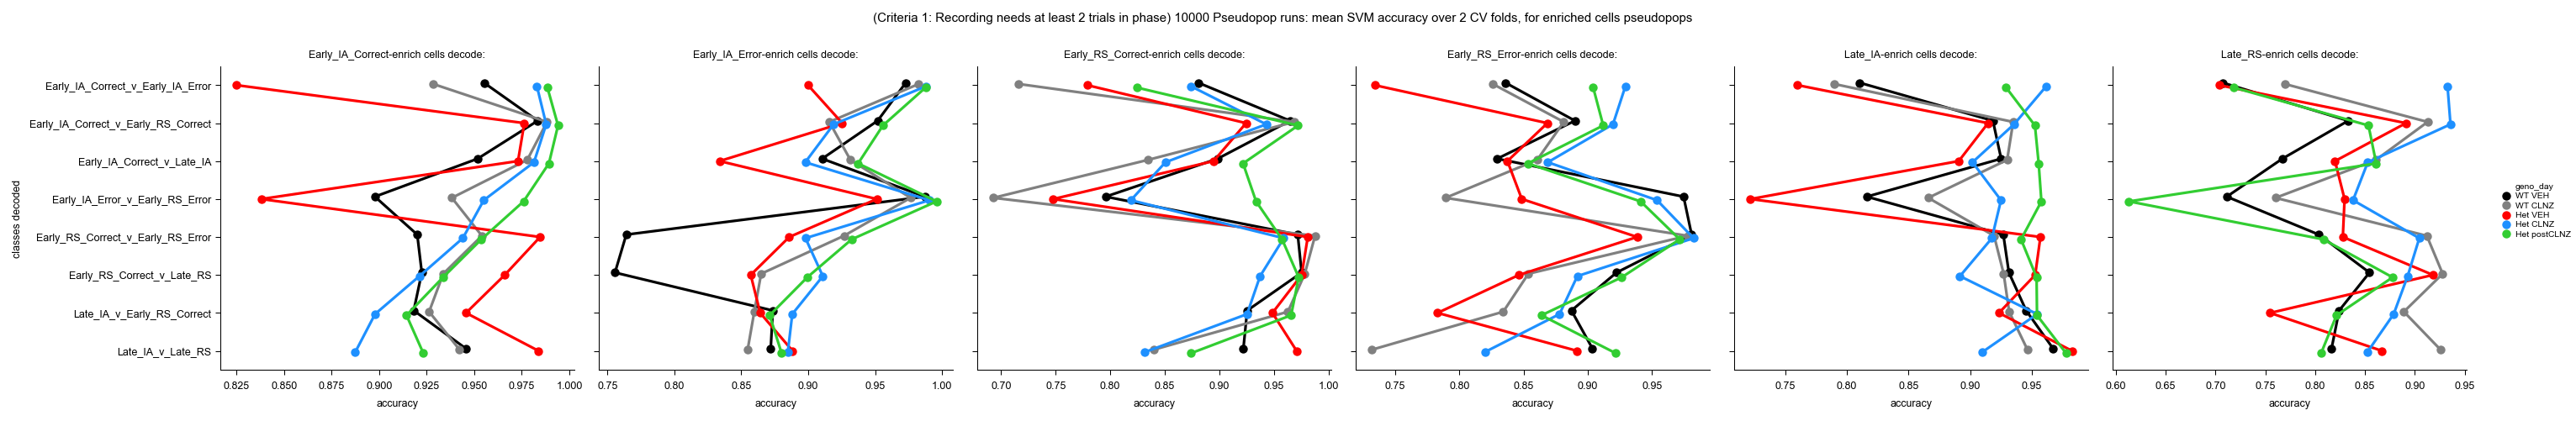

In [18]:
g = sns.catplot(kind = 'point', height = 3.3, data = pop_mean_decoding, dodge = True,sharey = True, sharex = False,col = 'enriched_group', y = 'classes decoded', x = 'accuracy', **geno_color_dict_w_WT_CLNZ)
g.fig.subplots_adjust(top = 0.85)
g.set_titles("{col_name}-enrich cells decode:")
g.fig.suptitle(f" (Criteria 1: Recording needs at least 2 trials in phase) {n_pseudopop_runs} Pseudopop runs: mean SVM accuracy over {k_folds} CV folds, for enriched {units} pseudopops")

## out of distribution generalizations

In [19]:
#create out of distribution handles
out_of_dist_train_sets = [
    [phase_names[0], phase_names[3]],#train on- early IA corr vs. early RS corr
     [phase_names[1], phase_names[4]],#train on- early IA err vs.l early RS err
    [phase_names[0], phase_names[1]],#train on-early IA corr vs. early IA err
    [phase_names[3], phase_names[4]],#train on- early RS corr vs. early RS err
    ]
out_of_dist_test_sets = [
    [phase_names[1], phase_names[4]],#test on- early IA err vs.l early RS err
    [phase_names[0], phase_names[3]],#test on- early IA corr vs. early RS corr
    [phase_names[3], phase_names[4]],##test on- early RS corr vs. early RS err
    [phase_names[0], phase_names[1]],##test on- early IA corr vs. early IA err
    ]
print(f"train sets: {out_of_dist_train_sets}")
print(f"Test sets: {out_of_dist_test_sets}")

train sets: [['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error'], ['Early_RS_Correct', 'Early_RS_Error']]
Test sets: [['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_RS_Correct', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error']]


#### Run parallel decoding to out of distribution

In [20]:
import itertools

In [ ]:

##aborted attempt at out of distribution decoding
# # function for out of distribution decoding
# def run_N_decoder_out_of_distribution(class_matrix_store,out_of_dist_train_sets, out_of_dist_test_sets, num_resample, n_pseudopop_run_range):
#     '''To- given a predefined range of numbers to uterate over as run #s, run SVM decoding thoese N times on ensemble, stage, and geno-day pairs  '''
#     all_run_record_store = []#create storage for all run information for later concat
#     #local var def 
#     test_size = 0.5
#     k_folds = 1
#     phase_names = class_matrix_store.keys()
#     for n_run in n_pseudopop_run_range:
#         for e_phase in phase_names:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
#             for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys(): #set geno to use
#                 ensemble_resample_in_phase_dict = {}
#                 for class_name in phase_names:
#                     class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, class_name, geno_day_curr)
#                     ensemble_resample_in_phase_dict[class_name] = class_matrix

#                 for phase_count, phase_pair in enumerate(out_of_dist_train_sets): #once genotype & enrichment filter, specified, compare phase detection
#                     class_0_train,class_1_train = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
#                     ## make training set
#                     class_mat_0_train =ensemble_resample_in_phase_dict[class_0_train]
#                     class_mat_1_train =ensemble_resample_in_phase_dict[class_1_train]
#                     concat_matrix_train,concat_labels_train, =fast_pack_data_local(class_mat_0_train, class_mat_1_train,0,1)        #returns .T.values of concat_matrix, and concat_labels
#                     split_info = []
#                     ##iterate over test pairs
#                     test_pair = out_of_dist_test_sets[phase_count]
#                     # for phase_count, test_pair in enumerate(out_of_dist_test_sets): #once genotype & enrichment filter, specified, compare phase detection
#                     class_0_test,class_1_test = test_pair[0], test_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
#                     class_mat_0_test =ensemble_resample_in_phase_dict[class_0_test]
#                     class_mat_1_test =ensemble_resample_in_phase_dict[class_1_test]
#                     concat_matrix_test,concat_labels_test, =fast_pack_data_local(class_mat_0_test, class_mat_1_test,0,1)        #returns .T.values of concat_matrix, and concat_labels
#                     #get test objects for current setup, aligning size of datasets
#                     unit_IDs_test =concat_matrix_test.index.values
#                     unit_IDs_train = concat_matrix_train.index.values
    
#                     train_IDs_in_test_bool = [u in unit_IDs_test for u in unit_IDs_train] #list of: unit in TEST_UNITS for unit in TRAIN_UNIT
#                     test_IDs_in_train_bool = [u in unit_IDs_train for u in unit_IDs_test]#list of: unit in Trin_UNITS for unit in Test_UNIT
#                     #now that IDs are extracted, pivot mats
#                     concat_matrix_test = concat_matrix_test.T.values
#                     concat_matrix_train = concat_matrix_train.T.values
#                     #restrict testing to units that have >0 activity in test and trian datasets
#                     concat_matrix_test= concat_matrix_test[:,test_IDs_in_train_bool]
#                     concat_matrix_train= concat_matrix_train[:,train_IDs_in_test_bool]
#                     #Train on entire generated train mat, test on the same 
#                     target_info = {"pseudopop_run_num": n_run, "enriched_group": e_phase,'geno_day': geno_day_curr,
#                                    'class_0_train' : class_0_train, 'class_1_train': class_1_train, 'class_0_test' : class_0_test, 'class_1_test': class_1_test, } #speficy info about what classes being decoded
#                     model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
#                     trained_model = model.fit(concat_matrix_train, concat_labels_train)                     # reorg_train_range, reorg_test_range = perm_range(len(concat_labels['train'])),  perm_range(len(concat_labels['test']))                     #reorder activity and labels to remove temporal ordering
#                     ## perdiction
#                     prediction_vec =trained_model.predict(concat_matrix_test)
#                     score_real = np.mean(prediction_vec == concat_labels_test)                      # precision, recall,score_real = get_test_precision_recall_acc( concat_matrix_test[test,:], concat_labels_test[test], trained_model)
                    
#                     true_pos= np.sum([np.array([prediction_vec == 1]) &  np.array([ concat_labels_test==1])])
#                     true_neg= np.sum([np.array([prediction_vec == 0]) &  np.array([ concat_labels_test==0])])
#                     false_pos =  np.sum([np.array([prediction_vec == 1]) &  np.array([ concat_labels_test==0])])
#                     false_neg =  np.sum([np.array([prediction_vec == 0]) &  np.array([ concat_labels_test==1])])
#                     ##NEW- 1.15.26- store cosine info
#                     # Compute mean vectors for all 4 class/set combinations
#                     mean_vectors = {
#                         'c0_train': concat_matrix_train[concat_labels_train == 0].mean(axis=0),
#                         'c1_train': concat_matrix_train[concat_labels_train == 1].mean(axis=0),
#                         'c0_test': concat_matrix_test[concat_labels_test == 0].mean(axis=0),
#                         'c1_test': concat_matrix_test[concat_labels_test == 1].mean(axis=0),
#                     }
#                     # Compute all pairwise cosine similarities
#                     cosine_sims = {}
#                     for (k1, v1), (k2, v2) in itertools.combinations(mean_vectors.items(), 2):
#                         cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
#                         cosine_sims[f'cosine_{k1}_v_{k2}'] = cos_sim
                        
#                     curr_split_info = { **target_info, 'mean_acc': score_real, 'num_features_used': trained_model.n_features_in_,
#                                        'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0),
#                                        'true_pos': true_pos,'true_neg':true_neg,'false_pos':false_pos, 'false_neg' :false_neg, **cosine_sims
#                                         }
                       
#                     all_run_record_store.append(curr_split_info)# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated
#                 #end of split loop, avg split performance and move on
#                     # average_acc = np.mean(split_performance)
#                     # split_summary = {**target_info,'mean_acc': average_acc} 
#                     # all_run_record_store.append(split_summary) #store performance information by split run
#                 #end of phase pair loop
#     all_run_record_store = pd.DataFrame.from_records(all_run_record_store)
#     return all_run_record_store

In [22]:
#create partial function and store real data 
# set up parallel batch- 10k shuff is 85 min
decode_type = "out_of_distribution"
n_jobs = 10
start_end_iter = make_chunked_iterator_of_ranges(0,n_pseudopop_runs, n_jobs)
start_end_iter
partial_param_svm_func = partial(run_N_decoder_out_of_distribution, class_matrix_store,out_of_dist_train_sets,  out_of_dist_test_sets, num_resample)
output_SVM_runs = Parallel(n_jobs= n_jobs, verbose = 9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
# 20j, 50batch of 1000- 11 min-5 9pm
print(len(output_SVM_runs))

N_batches: 10
Batch_size: 1000


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed: 21.3min remaining: 49.7min
[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed: 21.3min remaining: 21.3min
[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed: 21.7min remaining:  9.3min


10


[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed: 21.8min finished


In [23]:
## PACKAGE information into function ## versioning info
decode_scores = package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)
decode_scores['train_on'] = decode_scores.class_0_train.str.cat(decode_scores.class_1_train, sep = '_')
decode_scores['test_on'] = decode_scores.class_0_test.str.cat(decode_scores.class_1_test, sep = '_')

decode_file_name_out_distrib = output_folder / Path(f"Decode (Out of Distrib) {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet")
decode_scores.to_parquet(decode_file_name_out_distrib, compression='snappy')
print(f"decoding csv name: {decode_file_name_out_distrib}")
# decode_scores.to_csv(decode_file_name_out_distrib)
print(decode_scores.info())
decode_scores

decoding csv name: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\Decode (Out of Distrib) 10000 pseudopop post_outcome_activity 16_Jan_2026.parquet
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1200000 entries, 0 to 119999
Data columns (total 25 columns):
 #   Column                      Non-Null Count    Dtype         
---  ------                      --------------    -----         
 0   pseudopop_run_num           1200000 non-null  int32         
 1   enriched_group              1200000 non-null  object        
 2   geno_day                    1200000 non-null  object        
 3   class_0_train               1200000 non-null  object        
 4   class_1_train               1200000 non-null  object        
 5   class_0_test                1200000 non-null  object        
 6   class_1_test                1200000 non-null  object        
 7   mean_acc                    1200000 non-null  float64      

,pseudopop_run_num,enriched_group,geno_day,class_0_train,class_1_train,class_0_test,class_1_test,mean_acc,num_features_used,num_nonzero_coef,...,cosine_c0_train_v_c0_test,cosine_c0_train_v_c1_test,cosine_c1_train_v_c0_test,cosine_c1_train_v_c1_test,cosine_c0_test_v_c1_test,timebin_size,run_end_time,dataset_folder_name,train_on,test_on
0,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error,0.62500,76,74,...,0.571786,0.579245,0.364662,0.733600,0.433751,0.25,2026-01-16 01:37:04.314454,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error
1,0,Early_IA_Correct,Het CLNZ,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_RS_Correct,0.79875,76,60,...,0.571786,0.364662,0.579245,0.733600,0.573723,0.25,2026-01-16 01:37:04.314454,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct
2,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,0.52375,76,75,...,0.573723,0.579245,0.364662,0.433751,0.733600,0.25,2026-01-16 01:37:04.314454,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error
3,0,Early_IA_Correct,Het CLNZ,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Early_IA_Error,0.46125,76,48,...,0.573723,0.364662,0.579245,0.433751,0.571786,0.25,2026-01-16 01:37:04.314454,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error
4,0,Early_IA_Correct,Het VEH,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error,0.49750,33,25,...,0.502894,0.553228,0.480551,0.611331,0.394444,0.25,2026-01-16 01:37:04.314454,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,9999,Late_RS,WT CLNZ,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Early_IA_Error,0.47250,24,14,...,0.109182,0.172713,0.434232,0.460962,0.825488,0.25,2026-01-16 01:37:04.314454,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error
119996,9999,Late_RS,WT VEH,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error,0.45750,10,4,...,0.210439,0.338832,0.720152,0.000000,0.000000,0.25,2026-01-16 01:37:04.314454,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error
119997,9999,Late_RS,WT VEH,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_RS_Correct,0.48500,10,4,...,0.210439,0.720152,0.338832,0.000000,0.164803,0.25,2026-01-16 01:37:04.314454,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct
119998,9999,Late_RS,WT VEH,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,0.44500,10,5,...,0.164803,0.338832,0.720152,0.000000,0.000000,0.25,2026-01-16 01:37:04.314454,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error


In [24]:
## save metatdata of current run
f = open("last_generalize_decoding_run_info.txt", "w")
decode_run_info_str = f"latest generalize decoding output filename: {decode_file_name_out_distrib}. Run end: {date_tag}. Data used: {str(trial_df_filename)}"
f.write(decode_run_info_str)
f.close()
print(decode_run_info_str)

latest generalize decoding output filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\Decode (Out of Distrib) 10000 pseudopop post_outcome_activity 16_Jan_2026.parquet. Run end: 16_Jan_2026. Data used: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\python-made_trial_timeseries_raster_2025-12-21 12.parquet


## Decode out of distribution for single task

In [25]:
# function for out of distribution decoding
def run_N_decoder_out_of_distribution_test_single_stage(class_matrix_store,out_of_dist_train_sets,  out_of_dist_test_sets, num_resample, n_pseudopop_run_range):
    '''To- given a predefined range of numbers to uterate over as run #s, run SVM decoding thoese N times on ensemble, stage, and geno-day pairs  '''
    all_run_record_store = []#create storage for all run information for later concat
    #local var def 
    test_size = 0.5
    k_folds = 2
    phase_names = class_matrix_store.keys()
    for n_run in n_pseudopop_run_range:
        for e_phase in phase_names:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
            for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys(): #set geno to use
                ensemble_resample_in_phase_dict = {}
                for class_name in phase_names:
                    class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, class_name, geno_day_curr)
                    ensemble_resample_in_phase_dict[class_name] = class_matrix

                for phase_pair,class_test in zip(out_of_dist_train_sets,out_of_dist_test_sets): #once genotype & enrichment filter, specified, compare phase detection
                    class_0_train,class_1_train = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    ## make training set
                    class_mat_0_train =ensemble_resample_in_phase_dict[class_0_train]
                    class_mat_1_train =ensemble_resample_in_phase_dict[class_1_train]
                    concat_matrix_train,concat_labels_train, =fast_pack_data_local(class_mat_0_train, class_mat_1_train,0,1)        #returns .T.values of concat_matrix, and concat_labels
                    
                    unit_IDs_train = set(concat_matrix_train.index.values) #sets are faster for lookup
                    concat_matrix_train = concat_matrix_train.T.values
                    split_info = []
                    # class_test = out_of_dist_test_sets[phase_count] #because thsi is SINGLE STAGE TESTING, USE SINGLE OUTPUT 
                    #given resampling a single frame, do 2 resamples 
                    class_mat_0_test =ensemble_resample_in_phase_dict[class_test]
                    #redo resample on the lfy 
                    class_mat_1_test =resample_into_class_matrix(class_matrix_store,num_resample, e_phase,class_test, geno_day_curr)
                    concat_matrix_test,concat_labels_test, =fast_pack_data_local(class_mat_0_test, class_mat_1_test,0,1)        #returns .T.values of concat_matrix, and concat_labels
                    #get test objects for current setup, aligning size of datasets
                    unit_IDs_test = set(concat_matrix_test.index.values)
                   
                    #NEW METHOD- SET INTERSECTION-
                    common_IDs = list(unit_IDs_test & unit_IDs_train) #O(1) time
                    # use common_IDs to get indices
                    train_IDs_in_test = [u in common_IDs for u in unit_IDs_train]
                    test_IDs_in_train = [u in common_IDs for u in unit_IDs_test] #[true/false if u in common ID set for all u in test ID list
                    #now that IDs are extracted, pivot mats
                    concat_matrix_test = concat_matrix_test.T.values
                    #restrict testing to units that have >0 activity in test and trian datasets
                    assert concat_matrix_test.shape[1] == len(test_IDs_in_train), f" Error: test mat dim 1 ({concat_matrix_test.shape[1]} != index len {len(test_IDs_in_train)} in class_test {class_test} train pair {phase_pair}, ephase {e_phase}"
                    concat_matrix_test= concat_matrix_test[:,test_IDs_in_train]
                    concat_matrix_train= concat_matrix_train[:,train_IDs_in_test]

                    target_info = {"pseudopop_run_num": n_run, "enriched_group": e_phase,'geno_day': geno_day_curr,
                                   'class_0_train' : class_0_train, 'class_1_train': class_1_train, 'class_0_test' : class_test, 'class_1_test': class_test, } #speficy info about what classes being decoded
                    model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                    trained_model = model.fit(concat_matrix_train, concat_labels_train)                     # reorg_train_range, reorg_test_range = perm_range(len(concat_labels['train'])),  perm_range(len(concat_labels['test']))                     #reorder activity and labels to remove temporal ordering
                    ## perdiction
                    prediction_vec =trained_model.predict(concat_matrix_test)
                    score_real = np.mean(prediction_vec == concat_labels_test)                      # precision, recall,score_real = get_test_precision_recall_acc( concat_matrix_test[test,:], concat_labels_test[test], trained_model)
                    
                    predict_class_1 = np.mean(prediction_vec==1)
                    predict_class_0 = np.mean(prediction_vec==0)
                    ## new- add cosine sim of train class 1 and train class 2, to test class 1 (as there's only 1 test class)
                    mean_train_class_0 = concat_matrix_train[concat_labels_train ==0].mean(axis=0)
                    mean_train_class_1 = concat_matrix_train[concat_labels_train ==1].mean(axis=0)
                    mean_test_class_1 = concat_matrix_test.mean(axis=0)
                    cosine_train0_test1 = np.dot(mean_train_class_0, mean_test_class_1) / (np.linalg.norm(mean_train_class_0) * np.linalg.norm(mean_test_class_1))
                    cosine_train1_test1 = np.dot(mean_train_class_1, mean_test_class_1) / (np.linalg.norm(mean_train_class_1) * np.linalg.norm(mean_test_class_1))

                    curr_split_info = { **target_info, 'num_features_used': trained_model.n_features_in_,'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0),
                                       'predict_class_1': predict_class_1,'predict_class_0':predict_class_0, 
                                       'n_frames_test': concat_matrix_test.shape[0], 'n_frames_train':concat_matrix_train.shape[0], 
                                       'cosine_train0_test1': cosine_train0_test1, 'cosine_train1_test1': cosine_train1_test1,
                                       'mean_acc': score_real,
                                      }
                       
                    all_run_record_store.append(curr_split_info)# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated
                    #end of split loop, avg split performance and move on
                # average_acc = np.mean(split_performance)# split_summary = {**target_info,'mean_acc': average_acc} # all_run_record_store.append(split_summary) #store performance information by split run
            #end of phase pair loop
    all_run_record_store = pd.DataFrame.from_records(all_run_record_store)
    return all_run_record_store

In [26]:
single_stage_train_sets = [
    ['Early_IA_Correct', 'Early_IA_Error'],
    ['Early_IA_Correct', 'Early_IA_Error'],
    ['Early_IA_Correct', 'Early_RS_Correct'],
    ['Early_IA_Correct', 'Early_RS_Correct'],
    ['Early_IA_Error', 'Early_RS_Error'],
    ['Early_IA_Error', 'Early_RS_Error'],
]

single_stage_test_sets = [
    'Early_RS_Correct',
    'Early_RS_Error',
    'Early_IA_Error',
    'Early_RS_Error',
    'Early_IA_Correct',
    'Early_RS_Correct'
    ]
print(f"train:{ single_stage_train_sets}")
print(f"Test sets: {single_stage_test_sets}")

train:[['Early_IA_Correct', 'Early_IA_Error'], ['Early_IA_Correct', 'Early_IA_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Error', 'Early_RS_Error']]
Test sets: ['Early_RS_Correct', 'Early_RS_Error', 'Early_IA_Error', 'Early_RS_Error', 'Early_IA_Correct', 'Early_RS_Correct']


In [27]:
run_N_decoder_out_of_distribution_test_single_stage(class_matrix_store,single_stage_train_sets, single_stage_test_sets, num_resample, [0])

,pseudopop_run_num,enriched_group,geno_day,class_0_train,class_1_train,class_0_test,class_1_test,num_features_used,num_nonzero_coef,predict_class_1,predict_class_0,n_frames_test,n_frames_train,cosine_train0_test1,cosine_train1_test1,mean_acc
0,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Correct,76,75,0.51375,0.48625,800,800,0.407738,0.323851,0.47625
1,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_IA_Error,Early_RS_Error,Early_RS_Error,76,75,0.47625,0.52375,800,800,0.466717,0.202091,0.49125
2,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_IA_Error,76,74,0.55875,0.44125,800,800,0.495156,0.317624,0.51125
3,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_RS_Correct,Early_RS_Error,Early_RS_Error,108,105,0.78125,0.21875,800,800,0.522805,0.589287,0.50875
4,0,Early_IA_Correct,Het CLNZ,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_IA_Correct,76,60,0.20625,0.79375,800,800,0.479881,0.394100,0.51375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,0,Late_RS,WT VEH,Early_IA_Correct,Early_IA_Error,Early_RS_Error,Early_RS_Error,10,4,0.87750,0.12250,800,800,0.345946,0.000000,0.48000
176,0,Late_RS,WT VEH,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_IA_Error,15,13,0.32375,0.67625,800,800,0.061153,0.214985,0.49625
177,0,Late_RS,WT VEH,Early_IA_Correct,Early_RS_Correct,Early_RS_Error,Early_RS_Error,30,23,0.56875,0.43125,800,800,0.259903,0.186539,0.50875
178,0,Late_RS,WT VEH,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_IA_Correct,10,4,0.59875,0.40125,800,800,0.287459,0.230317,0.47125


In [28]:
#10k shuff- 50min
#create partial function and store real data  # set up parallel batch
decode_type = "out_of_distribution_single_stage"
n_jobs = 10
start_end_iter = make_chunked_iterator_of_ranges(0,n_pseudopop_runs, n_jobs)
start_end_iter
partial_param_svm_func = partial(run_N_decoder_out_of_distribution_test_single_stage, class_matrix_store,single_stage_train_sets, single_stage_test_sets, num_resample)
output_SVM_run_single_stage = Parallel(n_jobs= n_jobs, verbose = 9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
# 20j, 50batch of 1000- 11 min-5 9pm
print(len(output_SVM_run_single_stage))

N_batches: 10
Batch_size: 1000


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed: 33.0min remaining: 77.0min
[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed: 33.0min remaining: 33.0min
[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed: 33.4min remaining: 14.3min


10


[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed: 33.5min finished


In [29]:
## PACKAGE information into function ## versioning info
decode_scores = package_decode_scores_common(output_SVM_run_single_stage, hyper_param_dict, trial_df_filename)
decode_scores['train_on'] = decode_scores.class_0_train.str.cat(decode_scores.class_1_train, sep = '_')
decode_scores['test_on'] = decode_scores.class_0_test.str.cat(decode_scores.class_1_test, sep = '_')

decode_file_generalize_single_stage = output_folder / Path(f"Decode (single stage of Distrib) {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet")
decode_scores.to_parquet(decode_file_generalize_single_stage, compression='snappy')
print(f"decoding file name: {decode_file_generalize_single_stage}")
print(decode_scores.info())
decode_scores

decoding file name: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\Decode (single stage of Distrib) 10000 pseudopop post_outcome_activity 16_Jan_2026.parquet
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1800000 entries, 0 to 179999
Data columns (total 21 columns):
 #   Column               Dtype         
---  ------               -----         
 0   pseudopop_run_num    int32         
 1   enriched_group       object        
 2   geno_day             object        
 3   class_0_train        object        
 4   class_1_train        object        
 5   class_0_test         object        
 6   class_1_test         object        
 7   num_features_used    int64         
 8   num_nonzero_coef     int32         
 9   predict_class_1      float64       
 10  predict_class_0      float64       
 11  n_frames_test        int64         
 12  n_frames_train       int64         
 13  cosine_train0_test1  float64

,pseudopop_run_num,enriched_group,geno_day,class_0_train,class_1_train,class_0_test,class_1_test,num_features_used,num_nonzero_coef,predict_class_1,...,n_frames_test,n_frames_train,cosine_train0_test1,cosine_train1_test1,mean_acc,timebin_size,run_end_time,dataset_folder_name,train_on,test_on
0,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Correct,76,75,0.67125,...,800,800,0.387021,0.400114,0.50625,0.25,2026-01-16 02:10:40.924688,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Correct
1,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_IA_Error,Early_RS_Error,Early_RS_Error,76,75,0.56875,...,800,800,0.505922,0.356572,0.48125,0.25,2026-01-16 02:10:40.924688,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Error_Early_RS_Error
2,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_IA_Error,76,76,0.62250,...,800,800,0.391257,0.398153,0.52750,0.25,2026-01-16 02:10:40.924688,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_IA_Error
3,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_RS_Correct,Early_RS_Error,Early_RS_Error,108,105,0.83000,...,800,800,0.503016,0.545613,0.49500,0.25,2026-01-16 02:10:40.924688,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_RS_Error_Early_RS_Error
4,0,Early_IA_Correct,Het CLNZ,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_IA_Correct,76,60,0.24375,...,800,800,0.399000,0.398635,0.48875,0.25,2026-01-16 02:10:40.924688,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_IA_Correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179995,9999,Late_RS,WT VEH,Early_IA_Correct,Early_IA_Error,Early_RS_Error,Early_RS_Error,10,6,0.99375,...,800,800,0.029201,0.285051,0.50375,0.25,2026-01-16 02:10:40.924688,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Error_Early_RS_Error
179996,9999,Late_RS,WT VEH,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_IA_Error,15,9,0.08875,...,800,800,0.213220,0.185224,0.48625,0.25,2026-01-16 02:10:40.924688,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_IA_Error
179997,9999,Late_RS,WT VEH,Early_IA_Correct,Early_RS_Correct,Early_RS_Error,Early_RS_Error,30,22,0.79250,...,800,800,0.160210,0.097018,0.49750,0.25,2026-01-16 02:10:40.924688,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_RS_Error_Early_RS_Error
179998,9999,Late_RS,WT VEH,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_IA_Correct,10,4,1.00000,...,800,800,0.000000,0.501260,0.50000,0.25,2026-01-16 02:10:40.924688,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_IA_Correct


In [30]:
## save metatdata of current run
f = open("last_generalize_decoding_single_stage_run_info.txt", "w")
decode_run_info_str = f"latest generalize decoding output filename: {decode_file_generalize_single_stage}. Run end: {date_tag}. Data used: {str(trial_df_filename)}"
f.write(decode_run_info_str)
f.close()
print(decode_run_info_str)

latest generalize decoding output filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\Decode (single stage of Distrib) 10000 pseudopop post_outcome_activity 16_Jan_2026.parquet. Run end: 16_Jan_2026. Data used: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\python-made_trial_timeseries_raster_2025-12-21 12.parquet


## Time-dependent decoding:

#### setup time-dep decoding

In [31]:
def get_start_ends_of_sliced_range(length, chunk_size):
    """ 
    Divides a range of indices into N chunks, ensuring all chunks except the last are the same size.
    Args:
        length (int): The total length of the range.
        chunk_size (int): The size of chunks.
       Returns: np.ndarray: An array of (start, stop) tuples representing the chunk ranges.
    """
    # Compute the size of each chunk
    n_chunks = length // chunk_size
    # Create an array of start indices
    starts = np.arange(0, length, chunk_size)
    # Compute inclusive stop indices so each chunk has exactly chunk_size rows
    stops = starts + chunk_size - 1
    stops[-1] = length - 1
    return np.column_stack((starts, stops))


In [32]:
#function for bootstrapping PCA
def run_SVM_on_timebins_N_bootstrap(class_matrix_store,class_comparisons, frame_cols, num_resample:int,frame_batch_size, bootstrap_range):
    '''TO- run bootstrap to get cosine sim and sil score of decoded classes for each elem N in bootstrap_range '''
    output_list = [] #create class matrix store- DONE PREV
    stage_names = class_matrix_store.keys()
    geno_order = class_matrix_store['Late_IA']['Late_IA'].keys()
    #determine range slice creation
    if frame_batch_size is None: #if default argument, batch size == whole frame cols
        col_ranges = [(0, len(frame_cols))] 
    else:  
        col_ranges = get_start_ends_of_sliced_range(len(frame_cols), frame_batch_size)
        col_ranges= [tuple(row) for row in col_ranges]
    #run main body
    for b in bootstrap_range: #create B class matrix store (where b = number of resamples)
        for stage_enriched_in in stage_names:
            for geno_curr in geno_order:
                ensemble_resample_in_phase_dict = {}
                #if doing time-bin wise resampling, create range of mats to useabs             
                for class_name in stage_names: #store the versions for this bootstrap run
                    ensemble_resample_in_phase_dict[class_name]= dict() #allow for ranges for subsample to be used as keys 
                    for subset in col_ranges: #for each start/end value in ranges, draw a matrix within those frame cols of interest
                        subsample_range = frame_cols[subset[0]:subset[1]]
                        class_matrix = resample_into_class_matrix(class_matrix_store,num_resample,stage_enriched_in, class_name, geno_curr, 
                                                                  subsample_range=subsample_range)
                        ensemble_resample_in_phase_dict[class_name][subset] = class_matrix
    
                for phase_count, phase_pair in enumerate(class_comparisons): #once genotype & enrichment filter, specified, compare phase detection
                    class_0,class_1 = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    subset_info = []
                    
                    for subset in col_ranges: #for each start/end value in ranges, draw a matrix within those frame cols of interest
                        class_mat_0 =ensemble_resample_in_phase_dict[class_0][subset]
                        class_mat_1 =ensemble_resample_in_phase_dict[class_1][subset]
                        concat_matrix,concat_labels =fast_pack_data_local(class_mat_0, class_mat_1,0,1)        #returns concat_matrix, and concat_labels
                        concat_matrix = concat_matrix.values.T #.T.values of concat matrix is to reshape mat into what scikit wants from you
                        cv = model_selection.ShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices
                        
                        target_info = { 'pseudopop_run_num': b, 'enriched_group': stage_enriched_in,'class_0': class_0, 'class_1': class_1, 'geno_day': geno_curr, 
                                     'frame_subset': subset, 'bin_start_index': subset[0], 'bin_end_index': subset[1], 'bin_start_str': frame_cols[subset[0]], 
                                     } 
                        split_summary = []
                        for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels)), concat_labels)):
                            model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                            trained_model = model.fit(concat_matrix[train,:], concat_labels[train])                 # score_real = trained_model.score( concat_matrix[test,:], concat_labels[test])#get accuracy
                            precision, recall,score_real = get_test_precision_recall_acc( concat_matrix[test,:], concat_labels[test], trained_model)
                             #get correct bin names
                            if subset[1]==len(frame_cols):
                                bin_end_str = frame_cols[subset[1]-1]
                            else:
                                bin_end_str = frame_cols[subset[1]]   
                            #ending str = moved 1 index if index == length of acutal frame col, as you're indexing in exclusive manner
                            curr_split_info = {**target_info, 'mean_acc': score_real,'num_features_used': trained_model.n_features_in_,
                                               'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0), }
                                              
                           #     'train_pos_sample':  np.sum(concat_labels[train] ==1), 'train_neg_sample':np.sum(concat_labels[train] ==0), 
                           #                     'test_pos_sample':np.sum(concat_labels[train]==1), 'test_neg_sample': np.sum(concat_labels[train]==1),
                           # 'class_0_IDs': class_mat_0.index.values,
                           #                     'class_1_IDs':class_mat_1.index.values, 'date_run': datetime.today().strftime('%Y-%m-%d'),}
                            # curr_split_info = {**target_info,'split': split_count, 'mean_acc': score_real,}  
                            # split_summary =curr_split_info #gather performance for split N
                            split_summary.append(curr_split_info['mean_acc'])# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated
                        #save split info for the given subset
                        #after finishing split run, average then store
                        average_acc = np.mean(split_summary)
                        split_summary = {**target_info,'mean_acc': average_acc,'bin_end_str': bin_end_str, 'bin_default_size':frame_batch_size} 
                        output_list.append(split_summary) #append dict
                    # all_run_record_store.append(pd.DataFrame.from_records(split_summary)) #store performance information by split run
    #once done with all bootstraps, create from records
    output_list =pd.DataFrame.from_records(output_list)
    return output_list

In [33]:
%%time
frame_batch_size= 8
x = run_SVM_on_timebins_N_bootstrap(class_matrix_store,class_comparisons, numeric_col, 400,12, [1])
x

CPU times: total: 6.67 s
Wall time: 7.2 s


,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size
0,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(0, 11)",0,11,0.0s to 0.25s,0.97375,2.75s to 3.0s,12
1,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(12, 23)",12,23,3.0s to 3.25s,0.99250,5.75s to 6.0s,12
2,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(24, 35)",24,35,6.0s to 6.25s,0.99625,8.75s to 9.0s,12
3,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(36, 47)",36,47,9.0s to 9.25s,1.00000,11.75s to 12.0s,12
4,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(48, 59)",48,59,12.0s to 12.25s,1.00000,14.75s to 15.0s,12
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,1,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(0, 11)",0,11,0.0s to 0.25s,0.85625,2.75s to 3.0s,12
1196,1,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(12, 23)",12,23,3.0s to 3.25s,0.91250,5.75s to 6.0s,12
1197,1,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(24, 35)",24,35,6.0s to 6.25s,0.87500,8.75s to 9.0s,12
1198,1,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(36, 47)",36,47,9.0s to 9.25s,0.89750,11.75s to 12.0s,12


In [44]:
# set up parallel batch
num_resample = 400
n_jobs = 10
frame_batch_size= 24
n_bootstraps  = 10000
start_end_iter = make_chunked_iterator_of_ranges(0,n_bootstraps, n_jobs)
#12 min, 100 runs 
partial_timebin_svm_func = partial(run_SVM_on_timebins_N_bootstrap, class_matrix_store,class_comparisons,
                                   numeric_col, num_resample, frame_batch_size)
output_SVM_runs = Parallel(n_jobs= n_jobs, verbose = 9)(delayed(partial_timebin_svm_func)(x) for x in start_end_iter)
# 5 jobs, 100 per batch, 400 resamp, 12 frame/batch, 1000 bootstrap- 50min

N_batches: 10
Batch_size: 1000


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed: 103.5min remaining: 241.4min
[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed: 103.7min remaining: 103.7min
[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed: 104.0min remaining: 44.6min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed: 106.8min finished


In [45]:
## PACKAGE information into function ## versioning info
timedecode_scores= package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)
timedecode_scores['classes decoded'] = timedecode_scores.class_0.str.cat(timedecode_scores.class_1, sep = '_v_')#.astype('category')
timedecode_scores.head()

,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,timebin_size,run_end_time,dataset_folder_name,classes decoded
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(0, 23)",0,23,0.0s to 0.25s,0.99000,5.75s to 6.0s,24,0.25,2026-01-16 10:19:25.166169,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(24, 47)",24,47,6.0s to 6.25s,1.00000,11.75s to 12.0s,24,0.25,2026-01-16 10:19:25.166169,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(48, 59)",48,59,12.0s to 12.25s,0.99875,14.75s to 15.0s,24,0.25,2026-01-16 10:19:25.166169,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error
3,0,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,Het CLNZ,"(0, 23)",0,23,0.0s to 0.25s,0.99000,5.75s to 6.0s,24,0.25,2026-01-16 10:19:25.166169,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_RS_Correct
4,0,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,Het CLNZ,"(24, 47)",24,47,6.0s to 6.25s,0.99875,11.75s to 12.0s,24,0.25,2026-01-16 10:19:25.166169,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_RS_Correct


In [46]:

timedecode_scores = timedecode_scores.rename({'class_0': 'Phase1', 'class_1':'Phase2'}, axis = 1)
timedecode_scores['timebin_size'] = hyper_param_dict['bin_size']
timedecode_scores['run_end_time'] = datetime.now()
timedecode_scores['dataset_folder_name'] = str(trial_df_filename)
timedecode_scores.bin_start_str = timedecode_scores.bin_start_str.str.split(' to ').str[0]
timedecode_scores.bin_end_str = timedecode_scores.bin_end_str.str.split(' to ').str[1]
timedecode_scores['bin_name'] = timedecode_scores.bin_start_str.str.cat( timedecode_scores.bin_end_str, sep = ' to ')
timedecode_scores['frame_subset'] = timedecode_scores['frame_subset']#.astype('category')
timedecode_scores.loc[:,['enriched_group', 'Phase1','Phase2', 'geno_day']] = timedecode_scores.loc[:,['enriched_group', 'Phase1','Phase2', 'geno_day']]#.astype('category')
timedecode_scores.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7200000 entries, 0 to 719999
Data columns (total 17 columns):
 #   Column               Dtype         
---  ------               -----         
 0   pseudopop_run_num    int32         
 1   enriched_group       object        
 2   Phase1               object        
 3   Phase2               object        
 4   geno_day             object        
 5   frame_subset         object        
 6   bin_start_index      int32         
 7   bin_end_index        int32         
 8   bin_start_str        object        
 9   mean_acc             float64       
 10  bin_end_str          object        
 11  bin_default_size     int64         
 12  timebin_size         float64       
 13  run_end_time         datetime64[ns]
 14  dataset_folder_name  object        
 15  classes decoded      object        
 16  bin_name             object        
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(10)
memory usage: 906.4+ MB


In [59]:
timedecode_file_name = output_folder / Path( f"Timebin Decoding- {n_bootstraps}_bootstrap {data_type} {date_tag}.parquet")
timedecode_scores.to_parquet(timedecode_file_name, compression='snappy')
print(f"decoding file name: {timedecode_file_name}")
# timedecode_scores.to_csv(decode_csv_name)
print(timedecode_scores.info())
timedecode_scores

decoding file name: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\Timebin Decoding- 10000_bootstrap post_outcome_activity 16_Jan_2026.parquet
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7200000 entries, 0 to 719999
Data columns (total 17 columns):
 #   Column               Dtype         
---  ------               -----         
 0   pseudopop_run_num    int32         
 1   enriched_group       object        
 2   Phase1               object        
 3   Phase2               object        
 4   geno_day             object        
 5   frame_subset         object        
 6   bin_start_index      int32         
 7   bin_end_index        int32         
 8   bin_start_str        object        
 9   mean_acc             float64       
 10  bin_end_str          object        
 11  bin_default_size     int64         
 12  timebin_size         float64       
 13  run_end_time         datetime64[ns]
 14  da

,pseudopop_run_num,enriched_group,Phase1,Phase2,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,timebin_size,run_end_time,dataset_folder_name,classes decoded,bin_name
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(0, 23)",0,23,0.0s,0.99000,6.0s,24,0.25,2026-01-16 10:19:28.288721,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,0.0s to 6.0s
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(24, 47)",24,47,6.0s,1.00000,12.0s,24,0.25,2026-01-16 10:19:28.288721,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,6.0s to 12.0s
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(48, 59)",48,59,12.0s,0.99875,15.0s,24,0.25,2026-01-16 10:19:28.288721,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,12.0s to 15.0s
3,0,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,Het CLNZ,"(0, 23)",0,23,0.0s,0.99000,6.0s,24,0.25,2026-01-16 10:19:28.288721,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_RS_Correct,0.0s to 6.0s
4,0,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,Het CLNZ,"(24, 47)",24,47,6.0s,0.99875,12.0s,24,0.25,2026-01-16 10:19:28.288721,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_RS_Correct,6.0s to 12.0s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
719995,9999,Late_RS,Early_RS_Correct,Late_RS,WT VEH,"(24, 47)",24,47,6.0s,0.85500,12.0s,24,0.25,2026-01-16 10:19:28.288721,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_v_Late_RS,6.0s to 12.0s
719996,9999,Late_RS,Early_RS_Correct,Late_RS,WT VEH,"(48, 59)",48,59,12.0s,0.96625,15.0s,24,0.25,2026-01-16 10:19:28.288721,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_v_Late_RS,12.0s to 15.0s
719997,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(0, 23)",0,23,0.0s,0.88250,6.0s,24,0.25,2026-01-16 10:19:28.288721,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,0.0s to 6.0s
719998,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(24, 47)",24,47,6.0s,0.80375,12.0s,24,0.25,2026-01-16 10:19:28.288721,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,6.0s to 12.0s


In [60]:
## save metatdata of current run
f = open("last_time_decoding_run_info.txt", "w")
decode_run_info_str = f"latest time-based decoding output filename: {timedecode_file_name}. Run end: {date_tag}. Data used: {str(trial_df_filename)}"
f.write(decode_run_info_str)
f.close()
print(decode_run_info_str)

latest time-based decoding output filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\Timebin Decoding- 10000_bootstrap post_outcome_activity 16_Jan_2026.parquet. Run end: 16_Jan_2026. Data used: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\python-made_trial_timeseries_raster_2025-12-21 12.parquet


## save summaries of decoding performance

In [61]:
# Define mapping of decoding types to their output file variables
# Each entry: (decoding_type_name, output_file_variable_name)
decoding_types_config = [
    ('in_distribution', 'decode_file_name'),
    ('out_of_distribution', 'decode_file_name_out_distrib'),
    ('out_of_distribution_single_stage', 'decode_file_generalize_single_stage'),
    ('timebin_decoding', 'timedecode_file_name'),
]

# Create run info dataframes for all performed decoding types
run_info_dfs = []
for decoding_type, file_var_name in decoding_types_config:
    # Check if the output file variable exists (i.e., that decoding was performed)
    if file_var_name in dir():
        output_file = eval(file_var_name)
        run_info = {
            'run_date': date_tag, 
            'decoding_type': decoding_type, 
            'run_end_time': datetime.now(),
            'run_dataset_used': str(trial_df_filename),
            'run_output_filename': output_file, 
            'n_jobs': n_jobs,
            'n_iterations': n_pseudopop_runs if 'timebin' not in decoding_type else n_bootstraps, 
        }
        run_info_dfs.append(pd.DataFrame([run_info]))
        print(f"Created run info for: {decoding_type}")
    else:
        print(f"Skipped {decoding_type} - {file_var_name} not found (decoding not performed)")

# Concatenate all run info dataframes
current_runs_info = pd.concat(run_info_dfs, ignore_index=True)
current_runs_info

Created run info for: in_distribution
Created run info for: out_of_distribution
Created run info for: out_of_distribution_single_stage
Created run info for: timebin_decoding


,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations
0,16_Jan_2026,in_distribution,2026-01-16 10:59:26.084566,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000
1,16_Jan_2026,out_of_distribution,2026-01-16 10:59:26.099889,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000
2,16_Jan_2026,out_of_distribution_single_stage,2026-01-16 10:59:26.099889,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000
3,16_Jan_2026,timebin_decoding,2026-01-16 10:59:26.099889,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000


In [64]:

generalize_svm_record_file = f"Decoder- Out of Distribution - run version record.csv"
svm_file_loc = data_dir
if not os.path.exists(generalize_svm_record_file):    #create locally then save
    run_record_generalize = current_runs_info
else: #load and add to it 
    run_record_generalize= pd.read_csv(generalize_svm_record_file)
    run_record_generalize = pd.concat([run_record_generalize, current_runs_info])
    run_record_generalize = run_record_generalize.drop([c for c in run_record_generalize.columns if 'Unnamed' in c],axis = 1)
#if CSV doesn't exist, create
run_record_generalize.to_csv(generalize_svm_record_file)
run_record_generalize

,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations
0,16_Jan_2026,out_of_distribution,2026-01-16 02:21:06.545317,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000
1,16_Jan_2026,out_of_distribution_single_stage,2026-01-16 02:21:06.683581,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000
2,16_Jan_2026,in_distribution,2026-01-16 01:15:13.088077,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000
3,16_Jan_2026,out_of_distribution,2026-01-16 10:20:03.350180,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000
4,16_Jan_2026,out_of_distribution_single_stage,2026-01-16 10:20:03.483501,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000
5,16_Jan_2026,in_distribution,2026-01-16 01:15:13.088077,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000
6,16_Jan_2026,in_distribution,2026-01-16 10:56:47.569911,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000
7,16_Jan_2026,out_of_distribution,2026-01-16 10:56:47.576428,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000
8,16_Jan_2026,out_of_distribution_single_stage,2026-01-16 10:56:47.577429,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000
9,16_Jan_2026,in_distribution,2026-01-16 10:59:26.084566,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,10000


In [53]:
os.getcwd()

'C:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\results\\figure_5_prep_mid_decoding figures_16_Jan_2026'

In [ ]:
#all decoding names: 
# decoding file name: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\Timebin Decoding- 10000_bootstrap post_outcome_activity 16_Jan_2026.parquet
